In [1]:
!pip -q install pandas numpy matplotlib seaborn scipy openpyxl

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("figures", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

sns.set(style="whitegrid", context="talk")
np.random.seed(42)

In [3]:
pipelines = [
    "Base",
    "With_GSR",
    "Strict_Scrub",
    "No_Filter",
    "Alt_Atlas"
]

effects = pd.DataFrame({
    "pipeline": pipelines,
    "DMN_effect": [-0.72, -0.55, -0.69, -0.61, -0.66],
    "Salience_effect": [0.50, 0.41, 0.47, 0.44, 0.46],
    "FPN_effect": [0.30, 0.24, 0.28, 0.26, 0.27]
})

effects

,pipeline,DMN_effect,Salience_effect,FPN_effect
0,Base,-0.72,0.50,0.30
1,With_GSR,-0.55,0.41,0.24
2,Strict_Scrub,-0.69,0.47,0.28
3,No_Filter,-0.61,0.44,0.26
4,Alt_Atlas,-0.66,0.46,0.27


In [4]:
long_df = effects.melt(
    id_vars="pipeline",
    var_name="network",
    value_name="effect_size"
)

long_df["network"] = long_df["network"].str.replace("_effect", "")

long_df.head()

,pipeline,network,effect_size
0,Base,DMN,-0.72
1,With_GSR,DMN,-0.55
2,Strict_Scrub,DMN,-0.69
3,No_Filter,DMN,-0.61
4,Alt_Atlas,DMN,-0.66


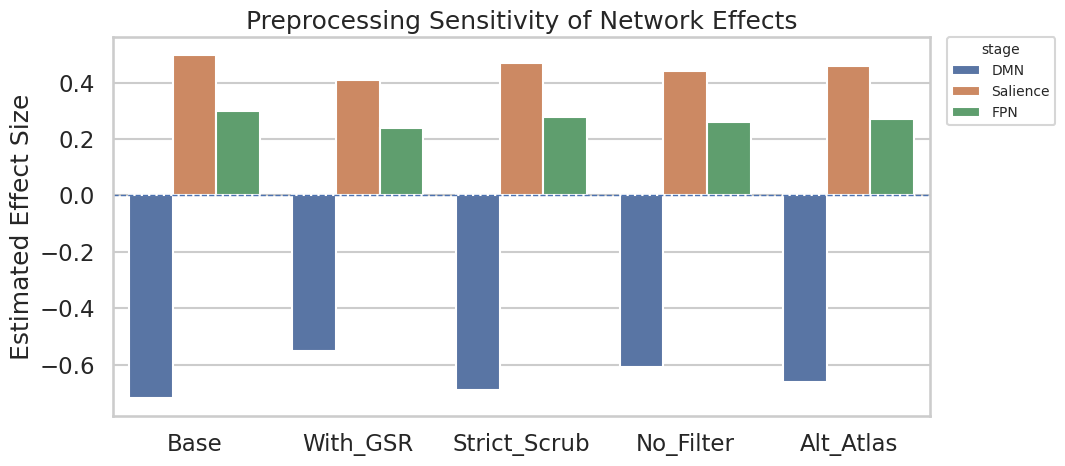

In [9]:
plt.figure(figsize=(11,5))

ax= sns.barplot(
    data=long_df,
    x="pipeline",
    y="effect_size",
    hue="network"
)

ax.legend(
    title="stage",
    fontsize=10,
    title_fontsize=10,
    markerscale=0.8,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("")
plt.ylabel("Estimated Effect Size")
plt.title("Preprocessing Sensitivity of Network Effects")
plt.tight_layout()
plt.savefig("figures/02_preprocessing_sensitivity.png", dpi=300)
plt.show()

In [6]:
pivot = effects.set_index("pipeline")

stability = pd.DataFrame({
    "network": ["DMN", "Salience", "FPN"],
    "std_across_pipelines": [
        pivot["DMN_effect"].std(),
        pivot["Salience_effect"].std(),
        pivot["FPN_effect"].std()
    ]
})

stability.to_csv("outputs/02_preprocessing_stability.csv", index=False)
effects.to_csv("outputs/02_pipeline_effects.csv", index=False)

stability

,network,std_across_pipelines
0,DMN,0.067305
1,Salience,0.033615
2,FPN,0.022361
